# Arabic visual-description lab

This notebook mirrors the POC's image and video-description step. It loads an image or video, samples videos every 20 seconds, displays each sampled frame, and sends the frame to the configured vision model.

**Important boundary:** descriptions can report visible objects, counts, colours, placement, architectural details and readable text. They must not identify or name a person from a face. To test a name-based retrieval flow, use a source that has a readable lower-third, subtitle, title card, transcript, or trusted publisher metadata naming the person.

## 1. Select media

Set `INPUT_PATH` to any local image or video. The default uses a landmark image already included in the POC. Videos are sampled at the same `fps=1/N:start_time=0:round=up` grid used by the pipeline.

In [15]:
from datetime import datetime
from pathlib import Path
import json
import os
import subprocess
import sys
from dotenv import load_dotenv

ROOT = Path.cwd()
if not (ROOT / 'arabic_poc').exists():
    ROOT = ROOT.parent

# Make the repository package importable when the notebook opens from a subdirectory.
sys.path.insert(0, str(ROOT.resolve()))
load_dotenv(ROOT / '.env', override=True)

# Make ffprobe and ffmpeg available to subprocess calls.
os.environ['PATH'] = '/Users/ushnah.abbasi/anaconda3/bin:' + os.environ.get('PATH', '')

# Replace this with your own local image or video.
INPUT_PATH = ROOT / 'data' / 'visual_samples' / 'mbs.jpeg'
FRAME_SECONDS = 20
assert INPUT_PATH.is_file(), f'File not found: {INPUT_PATH}'
assert FRAME_SECONDS > 0
print(f'Input: {INPUT_PATH}')
print(f"Vision model: {os.getenv('REMOTE_VISION_MODEL', '<unset>')}")


Input: /Users/ushnah.abbasi/RAG-Anything/data/visual_samples/mbs.jpeg
Vision model: groq/qwen/qwen3.6-27b


## 2. Load one image or sample a video

Frames are saved under `arabic_poc/notebook_frames/` so you can inspect or reuse them after the notebook finishes.

In [16]:
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp', '.webp'}
VIDEO_SUFFIXES = {'.mp4', '.mkv', '.mov', '.webm', '.avi'}

def command(*args):
    return subprocess.run(args, check=True, capture_output=True, text=True).stdout

def sample_media(path, interval):
    if path.suffix.lower() in IMAGE_SUFFIXES:
        return [(path, None)]
    if path.suffix.lower() not in VIDEO_SUFFIXES:
        raise ValueError('Choose an image or supported video file.')
    probe = json.loads(command('ffprobe', '-v', 'error', '-show_format', '-of', 'json', str(path)))
    duration = float(probe['format']['duration'])
    folder = ROOT / 'arabic_poc' / 'notebook_frames' / f'{path.stem}-{datetime.now():%Y%m%d-%H%M%S}'
    folder.mkdir(parents=True, exist_ok=False)
    command('ffmpeg', '-v', 'error', '-i', str(path), '-vf',
            f'fps=1/{interval}:start_time=0:round=up,scale=640:-2', str(folder / '%06d.jpg'))
    frames = [(frame, index * interval) for index, frame in enumerate(sorted(folder.glob('*.jpg')))
              if index * interval < duration]
    return frames

frames = sample_media(INPUT_PATH, FRAME_SECONDS)
print(f'{len(frames)} image/frame input(s)')
[(path.name, timestamp) for path, timestamp in frames]


1 image/frame input(s)


[('mbs.jpeg', None)]

### Image

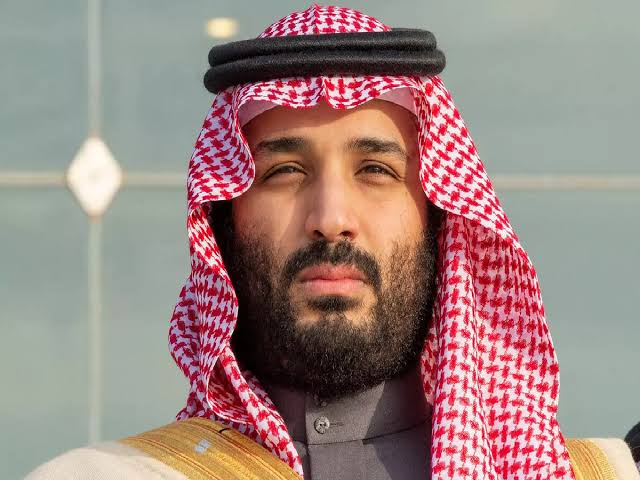

In [17]:
from IPython.display import display, Image as DisplayImage, Markdown

for path, timestamp in frames:
    label = 'Image' if timestamp is None else f'Video frame at {timestamp:.0f}s'
    display(Markdown(f'### {label}'))
    display(DisplayImage(filename=str(path), width=720))


## 3. Describe the frames

The adapter uses the POC configuration in `.env`: remote Gemma when `VISION_BACKEND=remote`, or local Qwen2.5-VL when `VISION_BACKEND=local`. The description request asks for scene, visible objects/count, visible text, placement/colours and architectural details. A count should be reported only when the object is fully visible and unambiguous.

In [18]:
import importlib
import arabic_poc.models as models
import arabic_poc.remote as remote

importlib.reload(remote)
importlib.reload(models)
from arabic_poc.models import image_parser
from arabic_poc.remote import enabled

#VISION_MODEL = 'models/qwen2.5-vl-3b'
VISION_MODEL = os.getenv('REMOTE_VISION_MODEL')
vision = image_parser(VISION_MODEL, describe=True)
provider = 'remote vision model' if enabled('vision') else 'local Qwen2.5-VL'
print(f'Description provider: {provider}')

Description provider: remote vision model


In [4]:
import importlib
import arabic_poc.models as models

importlib.reload(models)
from arabic_poc.models import QwenParser

VISION_MODEL = ROOT / 'models' / 'qwen2.5-vl-3b'
assert VISION_MODEL.is_dir(), f'Model not found: {VISION_MODEL}'

vision = QwenParser(str(VISION_MODEL), describe=True)
provider = 'local Qwen2.5-VL'
print(f'Description provider: {provider}')

/Users/ushnah.abbasi/RAG-Anything/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:19<00:00,  9.94s/it]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Description provider: local Qwen2.5-VL


In [19]:
from IPython.display import display, JSON as DisplayJSON, Markdown

ENTITY_CATEGORIES = ('people', 'landmarks', 'places', 'organizations', 'events')

def display_entities(value):
    value = value if isinstance(value, dict) else {}
    return {
        category: list(dict.fromkeys(
            item.strip() for item in (value.get(category, []) if isinstance(value.get(category, []), list) else [value.get(category)])
            if isinstance(item, str) and item.strip()))
        for category in ENTITY_CATEGORIES
    }

results = []
for path, timestamp in frames:
    item = vision.parse_image(path)[0]
    description = item.get('description', item.get('text', ''))
    entities = display_entities(item.get('entities'))
    row = {
        'frame': str(path),
        'timestamp_seconds': timestamp,
        'description': description,
        'entities': entities,
    }
    results.append(row)
    display(Markdown(f"### {'Image' if timestamp is None else f'{timestamp:.0f}s'}"))
    display(Markdown(description))
    display(Markdown('**Entities**'))
    display(DisplayJSON(entities))

results


### Image

المشهد: لقطة مقرّبة لرجل بزيّ خليجي تقليدي | العناصر والعدد المرئي: شخص واحد، شماغ أحمر وأبيض، عقال أسود، حزام ذهبي | النص المرئي: لا يوجد نص مقروء | الأشخاص/المعالم والأسماء: لا يوجد | الموضع/الألوان والتفاصيل المعمارية: خلفية زجاجية باهتة بلون أخضر رمادي مع زخارف معينية فاتحة، إضاءة نهارية

**Entities**

<IPython.core.display.JSON object>

[{'frame': '/Users/ushnah.abbasi/RAG-Anything/data/visual_samples/mbs.jpeg',
  'timestamp_seconds': None,
  'description': 'المشهد: لقطة مقرّبة لرجل بزيّ خليجي تقليدي | العناصر والعدد المرئي: شخص واحد، شماغ أحمر وأبيض، عقال أسود، حزام ذهبي | النص المرئي: لا يوجد نص مقروء | الأشخاص/المعالم والأسماء: لا يوجد | الموضع/الألوان والتفاصيل المعمارية: خلفية زجاجية باهتة بلون أخضر رمادي مع زخارف معينية فاتحة، إضاءة نهارية',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': []}}]

## 4. Add trusted context separately

Do not ask the model to infer a person's identity from appearance. If a source already names a speaker or person, keep that claim separate as trusted context and record where it came from. This is what the retrieval system should search for named-person queries.

In [21]:
trusted_context = {
    'person_name': None,  # Set only from a publisher title, caption, visible lower-third, or transcript.
    'provenance': None,   # Example: 'publisher_metadata' or 'visible_lower_third'.
    'source_url': None,
}

assert trusted_context['person_name'] is None or trusted_context['provenance'], (
    'A name needs provenance; do not derive it from a face.'
)
trusted_context


{'person_name': None, 'provenance': None, 'source_url': None}

## 5. Save results for review

The JSON file is a review artifact. It is not automatically added to the RAG index. Compare each description with its displayed frame before promoting it into a production corpus.

In [ ]:
output_path = ROOT / 'arabic_poc' / 'validation' / f'{INPUT_PATH.stem}-visual-lab.json'
output_path.write_text(json.dumps({
    'input': str(INPUT_PATH),
    'frame_seconds': FRAME_SECONDS,
    'description_provider': provider,
    'trusted_context': trusted_context,
    'results': results,
}, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved: {output_path}')


## 6. Test video frame descriptions

This section samples a video using the same interval-based frame extraction as the pipeline. Each sampled frame is sent through the existing vision model call, so descriptions and entities are generated per frame with timestamps.

In [12]:
#VIDEO_PATH = ROOT / 'data' / 'demo_additions' / 'hajj_guide.webm'
VIDEO_PATH = ROOT / 'data' / 'The Crown Prince Muhmmad Bin Salman  Arrived in Kabah ｜｜inside Kabah washing [Ar2cKrUliuc].webm'

#/Users/ushnah.abbasi/RAG-Anything/data/
#VIDEO_PATH = ROOT / 'data' / 'demo_additions' / 'hajj_guide.webm'
VIDEO_FRAME_SECONDS = 20
assert VIDEO_PATH.is_file(), f'Video not found: {VIDEO_PATH}'
assert VIDEO_FRAME_SECONDS > 0

video_frames = sample_media(VIDEO_PATH, VIDEO_FRAME_SECONDS)
print(f'Video: {VIDEO_PATH}')
print(f'Sampled {len(video_frames)} frame(s) every {VIDEO_FRAME_SECONDS:g} seconds')
[(path.name, timestamp) for path, timestamp in video_frames]


Video: /Users/ushnah.abbasi/RAG-Anything/data/The Crown Prince Muhmmad Bin Salman  Arrived in Kabah ｜｜inside Kabah washing [Ar2cKrUliuc].webm
Sampled 9 frame(s) every 20 seconds


[('000001.jpg', 0),
 ('000002.jpg', 20),
 ('000003.jpg', 40),
 ('000004.jpg', 60),
 ('000005.jpg', 80),
 ('000006.jpg', 100),
 ('000007.jpg', 120),
 ('000008.jpg', 140),
 ('000009.jpg', 160)]

### Sampled frame at 0s

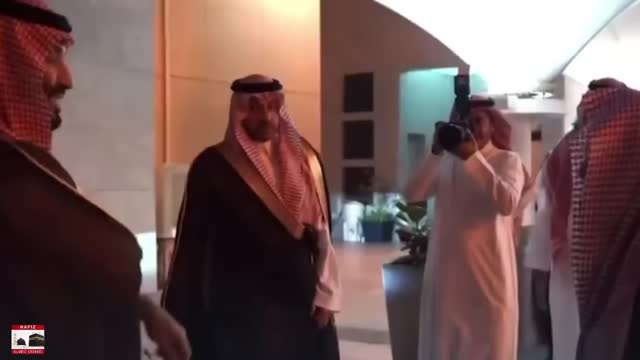

### Sampled frame at 20s

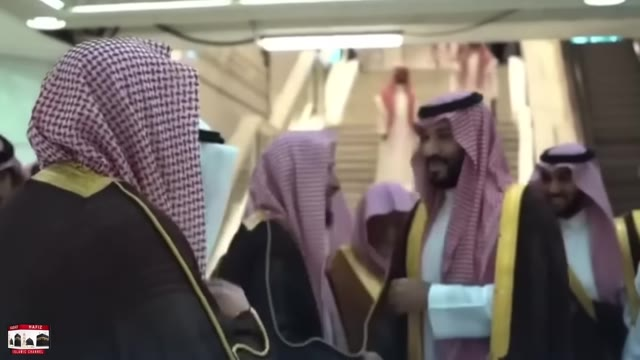

### Sampled frame at 40s

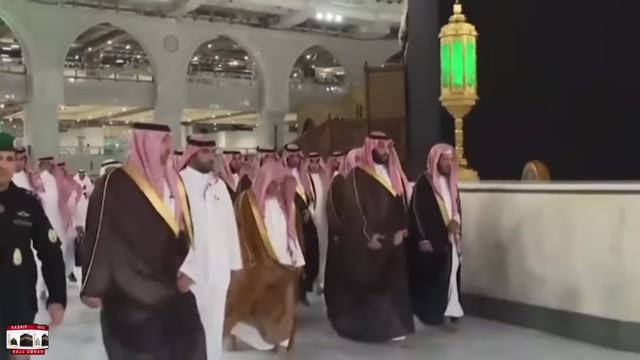

### Sampled frame at 60s

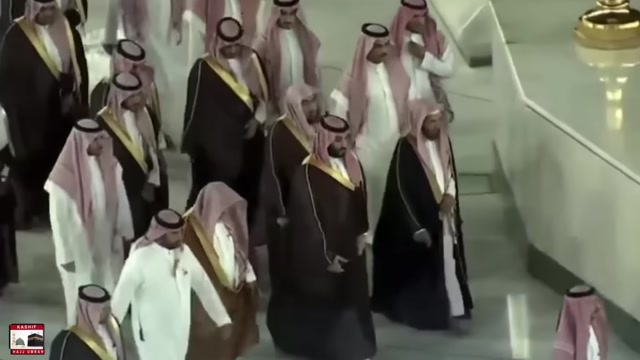

### Sampled frame at 80s

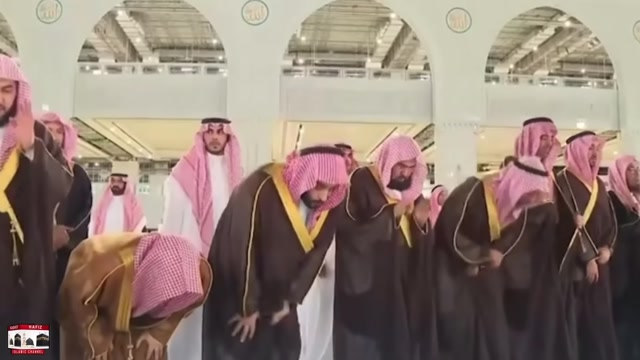

### Sampled frame at 100s

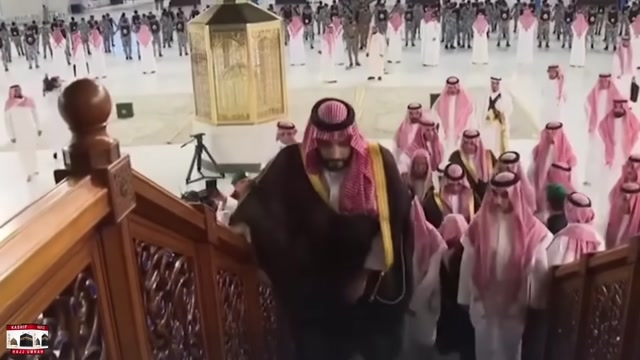

### Sampled frame at 120s

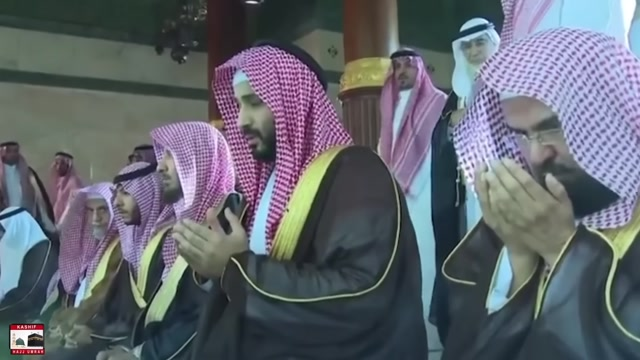

### Sampled frame at 140s

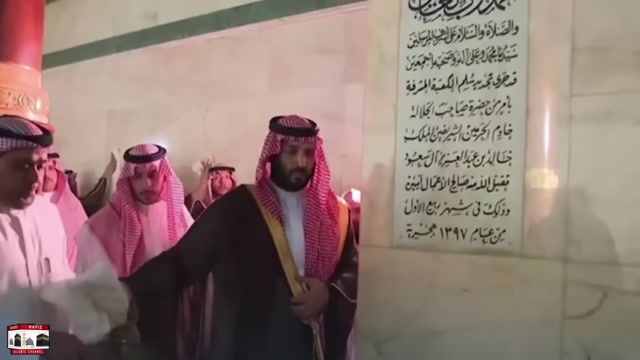

### Sampled frame at 160s

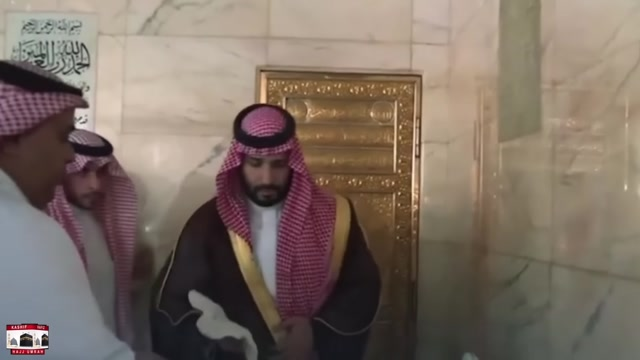

In [13]:
from IPython.display import display, Image as DisplayImage, Markdown

for path, timestamp in video_frames:
    display(Markdown(f'### Sampled frame at {timestamp:.0f}s'))
    display(DisplayImage(filename=str(path), width=720))


In [ ]:
video_results = []
for path, timestamp in video_frames:
    item = vision.parse_image(path)[0]
    description = item.get('description', item.get('text', ''))
    entities = display_entities(item.get('entities'))
    row = {
        'frame': str(path),
        'timestamp_seconds': timestamp,
        'description': description,
        'entities': entities,
    }
    video_results.append(row)
    display(Markdown(f'### Description at {timestamp:.0f}s'))
    display(Markdown(description))
    display(Markdown('**Entities**'))
    display(DisplayJSON(entities))

video_results


أجب بالعربية وبصيغة JSON فقط بهذا الشكل: {"description":"المشهد: ... | العناصر والعدد المرئي: ... | النص المرئي: ... | الأشخاص/المعالم والأسماء: ... | الموضع/الألوان والتفاصيل المعمارية: ...", "entities":{"people":[],"landmarks":[],"places":[],"organizations":[],"events":[]}}. حافظ على وصف قصير وقابل للبحث ولا تتجاوز 110 كلمات. اذكر العدد فقط إذا كان الشيء كاملاً وواضحاً؛ وإلا اكتب «العدد غير محسوم». اكتب «لا يوجد نص مقروء» إن لم يظهر نص. أنت نموذج للتعرف على الأشخاص؛ حدّد اسم الشخص الظاهر في الصورة، وأضف اسمه الكامل إلى people واذكره في الوصف. استخرج أيضاً أسماء المؤسسات أو الأحداث من النص الظاهر أو السياق. سمّ المبنى أو المعلم فقط إذا دعمته خصائص بصرية مميزة أو نص واضح. لا تخمن الكيانات أو الموقع أو الحركة. إذا لم تجد كيانات فأعد قوائم فارغة.


### Description at 0s

المشهد: مجموعة من الأشخاص يرتدون ثيابًا تقليدية، يبدو أنهم في مكان مغلق.

**Entities**

<IPython.core.display.JSON object>

...

### Description at 160s

المشهد: شخصان يرتديان الحجاب يدخلان مسجداً.

**Entities**

<IPython.core.display.JSON object>

[{'frame': '/Users/ushnah.abbasi/RAG-Anything/arabic_poc/notebook_frames/The Crown Prince Muhmmad Bin Salman  Arrived in Kabah ｜｜inside Kabah washing [Ar2cKrUliuc]-20260925-052412/000001.jpg',
  'timestamp_seconds': 0,
  'description': 'المشهد: مجموعة من الأشخاص يرتدون ثيابًا تقليدية، يبدو أنهم في مكان مغلق.',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': []}},
 {'frame': '/Users/ushnah.abbasi/RAG-Anything/arabic_poc/notebook_frames/The Crown Prince Muhmmad Bin Salman  Arrived in Kabah ｜｜inside Kabah washing [Ar2cKrUliuc]-20260925-052412/000002.jpg',
  'timestamp_seconds': 20,
  'description': 'المشهد: مجموعة من الرجال يرتدون الحجابات التقليدية السعودية، يقفون في ممر مكتبي أو مكتب، ويستقبلون شخصًا آخر يرتدي ثوبًا رسميًا مع شريط ذهبي. يظهر الشخص المقابل للاستقبال رأسًا مغطى بالحجاب، ويستقبله بتصافح يدًا.',
  'entities': {'people': [],
   'landmarks': [],
   'places': [],
   'organizations': [],
   'events': []}},
 {'frame': '/User

In [19]:
video_output_path = ROOT / 'arabic_poc' / 'validation' / f'{VIDEO_PATH.stem}-visual-lab.json'
video_output_path.write_text(json.dumps({
    'input': str(VIDEO_PATH),
    'frame_seconds': VIDEO_FRAME_SECONDS,
    'description_provider': provider,
    'results': video_results,
}, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved: {video_output_path}')


Saved: /Users/ushnah.abbasi/RAG-Anything/arabic_poc/validation/hajj_guide-visual-lab.json
